<p style="font-family:Nazanin; font-size:140%; text-align:center;" dir="rtl">
   «تحلیل داده‌ آگهی‌های دیوار»
</p>

In [ ]:
#!py -3.12 -m pip install geopy
#!py -3.12 -m pip install requests
#!py -3.12 -m pip install time

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری کتابخانه های مورد نیاز
</p>

In [12]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import warnings
warnings.filterwarnings("ignore")

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
بارگذاری داده های مورد نیاز
</p>

In [2]:
#data = pd.read_csv('/content/divar_real_estate_ads.csv', encoding="utf-8")
data = pd.read_csv('/content/sampled_data.csv',encoding = 'utf-8', engine='python')

<p style="font-family:Nazanin; font-size:130%; text-align:right;color:blue;" dir="rtl">
    بخش اول : بررسی کیفیت داده
</p>
<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    1. مقادیر ناموجود در هر یک از ستون‌ها را بررسی و ستون‌ها و ردیف‌هایی که مقادیر موجود بیشتری دارند را مشخص کنید .
</p>

In [3]:
df_na = data.isna().sum().reset_index()
df_na.columns = ["column", "missing_nums"]
df_na["percent_missing"] = (df_na["missing_nums"] / len(data)) * 100
# sort columns from lowest number of NA's to the highest
df_na = df_na.sort_values(by="percent_missing", ascending=True)
print("columns with lowest number of NA's")
print(df_na.head(5))
print("\n")
print("columns with highest number of NA's")
print((df_na.tail(5)))

columns with lowest number of NA's
             column  missing_nums  percent_missing
0         cat2_slug             0          0.00000
1         cat3_slug             1          0.00575
2         city_slug             1          0.00575
4  created_at_month             1          0.00575
6       description             1          0.00575


columns with highest number of NA's
                        column  missing_nums  percent_missing
54  rent_price_on_regular_days         17082        98.223219
56      rent_price_at_weekends         17170        98.729228
55  rent_price_on_special_days         17209        98.953482
53       cost_per_extra_person         17214        98.982232
10              rent_to_single         17391       100.000000


<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    2. آیا ردیف‌های تکراری در داده وجود دارد؟
</p>

In [4]:
print('number of duplicated rows: ',data.duplicated(keep = 'last').sum())


number of duplicated rows:  0


<p style="font-family:Nazanin; font-size:130%; text-align:right;color:blue;" dir="rtl">
    بخش دوم : تحلیل اکتشافی داده (EDA)
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    1. توزیع و مشخصه‌های آماری هر یک از ستون‌ها (متغیرهای عددی) را ترسیم و بررسی کنید.
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    2. ارتباط دو به دوی تعدادی از متغیرها را که تصور می‌کنید به فهم داده کمک می‌کنند، بررسی کنید.
</p>

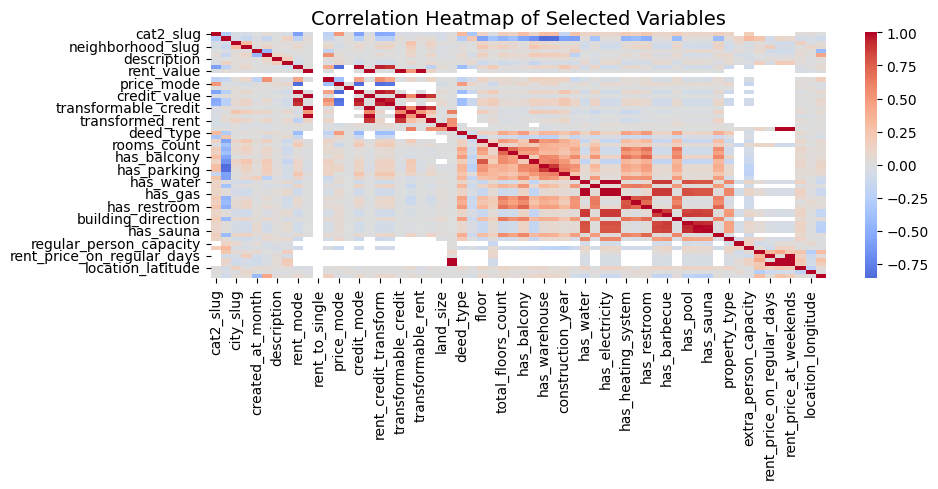

Pairs of columns with absolute correlation > 0.8:
there is strong negative correlation between price_mode - rent_mode: -0.847 

there is strong positive correlation between credit_mode - rent_mode: 0.985 

there is strong negative correlation between credit_mode - price_mode: -0.859 

there is strong positive correlation between credit_value - rent_value: 0.988 

there is strong positive correlation between rent_credit_transform - rent_mode: 0.943 

there is strong negative correlation between rent_credit_transform - price_mode: -0.826 

there is strong positive correlation between rent_credit_transform - credit_mode: 0.958 

there is strong positive correlation between transformable_price - rent_mode: 0.908 

there is strong positive correlation between transformable_price - credit_mode: 0.923 

there is strong positive correlation between transformable_price - rent_credit_transform: 0.943 

there is strong positive correlation between transformable_credit - rent_value: 0.988 

there 

In [ ]:

data_clean = data.copy()

# Convert booleans-like strings to numeric 1/0
bool_cols = [c for c in data_clean.columns if data_clean[c].dtype == 'object' and
             set(data_clean[c].dropna().unique()).issubset({'TRUE', 'FALSE', 'True', 'False','true','false'})]

for col in bool_cols:
    data_clean[col] = data_clean[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})

# Convert categorical columns to category codes
for col in data_clean.columns:
    if data_clean[col].dtype == 'object':
        data_clean[col] = data_clean[col].astype('category').cat.codes


#save this dataframe for later process
#data_clean.to_csv('divar_clean.csv',index = False)

corr_matrix = data_clean.corr(numeric_only=True)

# Visualize correlations (heatmap)
plt.figure(figsize=(10,5))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap of Selected Variables', fontsize=14)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300)
plt.show()

#findout the correlation between values in corr_matrix
high_corr_pairs = []
# Iterate through the correlation matrix
for i in range(len(corr_matrix.columns)):
    for j in range(i): # Start from j=0 to avoid duplicate pairs and the diagonal
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            correlation_value = corr_matrix.iloc[i, j]
            high_corr_pairs.append((col1, col2, correlation_value))

# Print the pairs
print("Pairs of columns with absolute correlation > 0.8:")
for pair in high_corr_pairs:
    if pair[2] > 0 :
      print(f"there is strong positive correlation between {pair[0]} - {pair[1]}: {pair[2]:.3f} \n")
    else:
      print(f"there is strong negative correlation between {pair[0]} - {pair[1]}: {pair[2]:.3f} \n")


<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. نکات قابل توجهی را که از بررسی توزیع‌ها و نمودارهای پراکندگی و مقدار همبستگی دریافتید فهرست کنید.
</p>

<p style="font-family:Nazanin; font-size:100%; text-align:right;" dir="rtl">
    3. آیا چیزی از جنس تناقض و ناسازگاری مقداری در داده مشاهده می‌کنید؟ به عنوان نمونه به این صورت که در یک سلول مقدار غیرمرتبط و از نظر منطقی نادرست نوشته شده باشد. مثلا در ستونی که قرار است متن بیاید عدد آمده باشد یا در ستونی که قرار است عدد یک یا دو رقمی بیاید، مقدار متفاوتی ثبت شده است.
</p>

# from here  ....

In [5]:
#calculate price per square meter and rent per square meter
data2 = data.copy()
data2['price_per_meter'] = (data2['price_value'] / data2['building_size'])/1000000

#since we have credit and rent price we need total rent
data2['total_rent'] = data2['rent_value']*30 + data2['credit_value']
data2['rent_price_per_meter'] = (data2['total_rent'] / data2['building_size'])/1000000

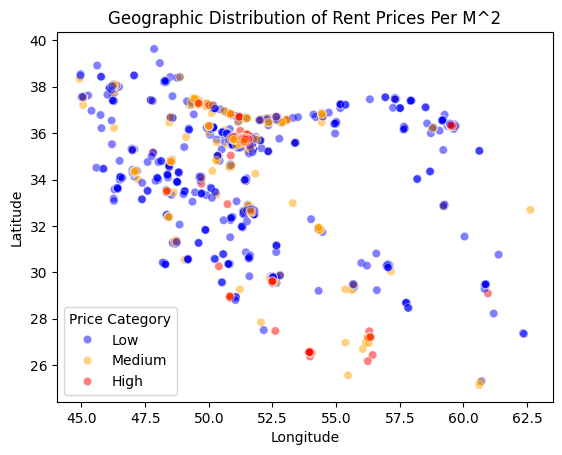

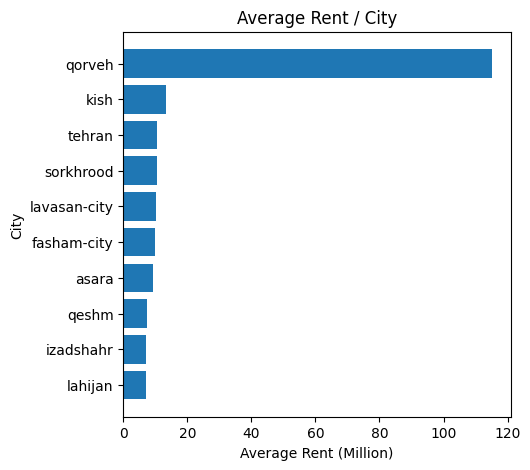

In [ ]:
# Calculate Q1, Q3, and IQR for 'price_value'
Q1 = data2['total_rent'].quantile(0.25)
Q3 = data2['total_rent'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers and filter the data based on the index of non-outliers

data4 = data2[(data2['cat2_slug']=='residential-rent') &
              (data2['cat3_slug']=='apartment-rent') &
              (data2['total_rent'] > lower_bound) &
              (data2['total_rent'] < upper_bound)]

bins = [data4['rent_price_per_meter'].min()-1, data4['rent_price_per_meter'].quantile(0.33),
       data4['rent_price_per_meter'].quantile(0.66), data4['rent_price_per_meter'].max()+1]
labels = ['Low', 'Medium', 'High']

data4['price_category'] = pd.cut(data4['rent_price_per_meter'], bins=bins, labels=labels)


sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=data4,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.5
)
plt.title('Geographic Distribution of Rent Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.show()

avg_rent_per_city = data4.groupby('city_slug')['rent_price_per_meter'].mean().reset_index()
avg_rent_per_city = avg_rent_per_city.sort_values('rent_price_per_meter', ascending=False)
avg_rent_per_city[avg_rent_per_city['rent_price_per_meter'].notnull()]
avg_rent_per_city = avg_rent_per_city.head(10)
plt.figure(figsize = (5, 5))

plt.barh(
    avg_rent_per_city['city_slug'],
    avg_rent_per_city['rent_price_per_meter']
)
plt.xlabel('Average Rent (Million)')
plt.ylabel('City')
plt.title('Average Rent / City')
plt.gca().invert_yaxis()
plt.show()



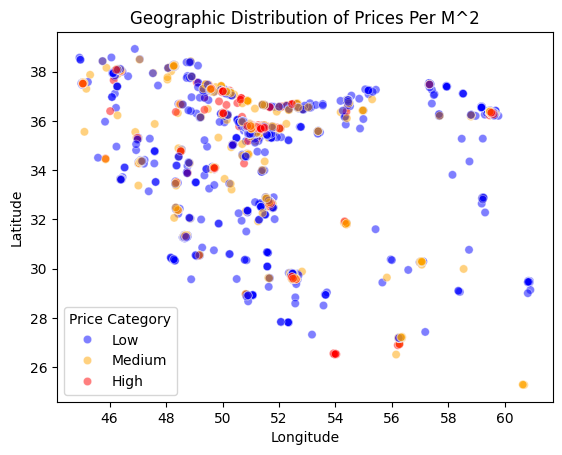

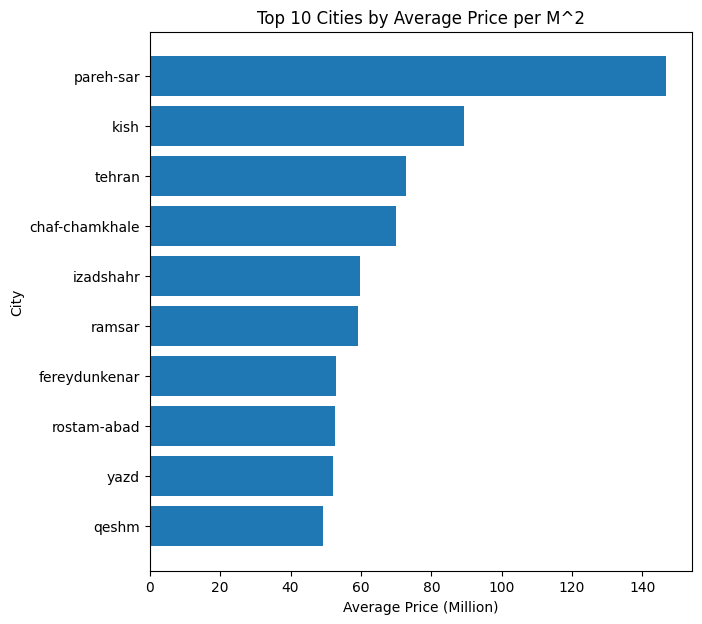

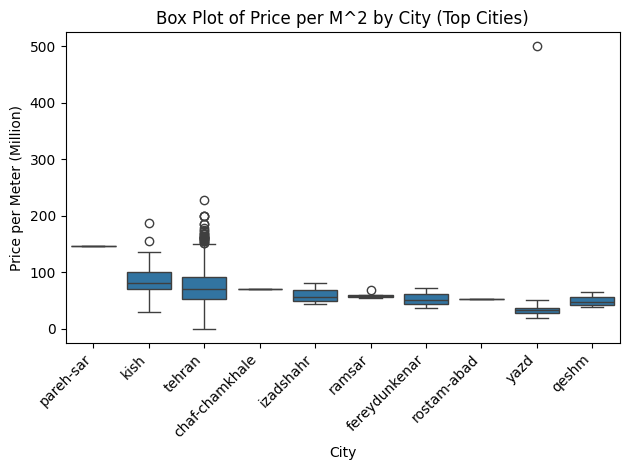

In [ ]:
# Calculate Q1, Q3, and IQR for 'price_value'
Q1 = data2['price_value'].quantile(0.25)
Q3 = data2['price_value'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Find the outliers and filter the data based on the index of non-outliers

data3 = data2[(data2['cat2_slug']=='residential-sell') &
              (data2['cat3_slug']=='apartment-sell') &
              (data2['price_value'] > lower_bound) &
              (data2['price_value'] < upper_bound)]

bins = [data3['price_per_meter'].min()-1, data3['price_per_meter'].quantile(0.33),
       data3['price_per_meter'].quantile(0.66), data3['price_per_meter'].max()+1]
labels = ['Low', 'Medium', 'High']

data3['price_category'] = pd.cut(data3['price_per_meter'], bins=bins, labels=labels)


sns.scatterplot(
    x='location_longitude',
    y='location_latitude',
    hue='price_category',
    data=data3,
    palette={'Low':'blue', 'Medium':'orange', 'High':'red'},
    alpha=0.5
)
plt.title('Geographic Distribution of Prices Per M^2')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title='Price Category')
plt.show()



avg_price_per_city = data3.groupby('city_slug')['price_per_meter'].mean().reset_index()
avg_price_per_city = avg_price_per_city.sort_values('price_per_meter', ascending=False)

avg_price_per_city = avg_price_per_city[avg_price_per_city['price_per_meter'].notnull()]

# Select top 10 cities for the bar chart
avg_price_per_city_top10 = avg_price_per_city.head(10)


plt.figure(figsize = (7, 7))
plt.barh(
    avg_price_per_city_top10['city_slug'],
    avg_price_per_city_top10['price_per_meter']
)
plt.xlabel('Average Price (Million)')
plt.ylabel('City')
plt.title('Top 10 Cities by Average Price per M^2')
plt.gca().invert_yaxis()
plt.show()

top_cities = avg_price_per_city.head(10)['city_slug'].tolist()
data3_top_cities = data3[data3['city_slug'].isin(top_cities)].copy()

#plt.figure(figsize=(7, 7))
sns.boxplot(x='city_slug', y='price_per_meter', data=data3_top_cities, order=top_cities) # Order by average price
plt.title('Box Plot of Price per M^2 by City (Top Cities)')
plt.xlabel('City')
plt.ylabel('Price per Meter (Million)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate Q1, Q3, and IQR for 'price_value'
Q1 = data2['price_value'].quantile(0.25)
Q3 = data2['price_value'].quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR


data3 = data2[(data2['cat2_slug']=='residential-sell') &
              (data2['cat3_slug']=='apartment-sell') &
              (data2['price_value'] > lower_bound) &
              (data2['price_value'] < upper_bound)]

In [ ]:

data2_copy = data2.copy()
# Calculate Q1, Q3, and IQR for 'price_value'
Q1_p = data2['price_per_meter'].quantile(0.25)
Q3_p = data2['price_per_meter'].quantile(0.75)
IQR_p = Q3_p - Q1_p

# Define the lower and upper bounds for outliers
lower_bound_p = Q1_p - 1.5 * IQR_p
upper_bound_p = Q3_p + 1.5 * IQR_p

Q1_r = data2['rent_price_per_meter'].quantile(0.25)
Q3_r = data2['rent_price_per_meter'].quantile(0.75)
IQR_r = Q3_r - Q1_r

# Define the lower and upper bounds for outliers
lower_bound_r = Q1_r - 1.5 * IQR_r
upper_bound_r = Q3_r + 1.5 * IQR_r

data2_copy = data2_copy[(data2_copy['price_per_meter'] > lower_bound_p) & (data2_copy['price_per_meter'] < upper_bound_p) |
                   (data2_copy['rent_price_per_meter'] > lower_bound_r) & (data2_copy['rent_price_per_meter'] < upper_bound_r)
                   ]



data2_copy.shape

(31347, 63)

In [ ]:
avg_price_per_year = data2_copy.groupby('construction_year')['price_per_meter'].mean().reset_index()
avg_price_per_year = avg_price_per_year.sort_values('construction_year', ascending=True)
avg_price_per_year = avg_price_per_year[avg_price_per_year['price_per_meter'].notnull()]

#plt.figure(figsize = (15, 5))
sns.scatterplot(x = 'construction_year', y = 'price_per_meter', data = avg_price_per_year)
plt.title('Construction_year / price_per_meter')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
avg_rent_per_year = data2_copy.groupby('construction_year')['rent_price_per_meter'].mean().reset_index()
avg_rent_per_year = avg_rent_per_year.sort_values('construction_year', ascending=True)
avg_rent_per_year = avg_rent_per_year[avg_rent_per_year['rent_price_per_meter'].notnull()]

#plt.figure(figsize = (10, 5))
sns.scatterplot(x = 'construction_year', y = 'rent_price_per_meter', data = avg_rent_per_year)
plt.title('Construction_year / rent_per_meter')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

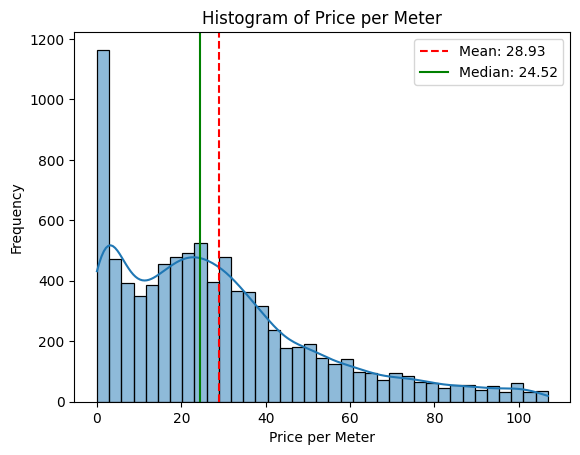

In [6]:
from scipy.stats import skew
data2_copy = data2.copy()
# Calculate Q1, Q3, and IQR for 'price_value'
Q1_p = data2['price_per_meter'].quantile(0.25)
Q3_p = data2['price_per_meter'].quantile(0.75)
IQR_p = Q3_p - Q1_p

# Define the lower and upper bounds for outliers
lower_bound_p = Q1_p - 1.5 * IQR_p
upper_bound_p = Q3_p + 1.5 * IQR_p

data2_copy = data2_copy[(data2_copy['price_per_meter'] > lower_bound_p) & (data2_copy['price_per_meter'] < upper_bound_p)]
#pd.save

#data2_copy.shape
#print(skew(data2[data2['price_per_meter'].notnull()]['price_per_meter']))
#print(skew(data2[data2['rent_price_per_meter'].notnull()]['rent_price_per_meter']))
#print(skew(data2['rent_price_per_meter']))

price_per_meter = data2_copy[data2_copy['price_per_meter'].notnull()]['price_per_meter'].round(2)

mean = np.mean(price_per_meter)
median = np.median(price_per_meter)

sns.histplot(price_per_meter, kde=True)


plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f}')


plt.axvline(median, color='green', linestyle='-', label=f'Median: {median:.2f}')

plt.title('Histogram of Price per Meter')
plt.xlabel('Price per Meter')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [16]:
#داده های قبل و بعد از چارک اول و سوم که به عنوان پرت در نظر گرفته شده است  جدا شده اند
data_less_Q1 = data2[data2['price_per_meter']<Q1_p]
data_big_Q3 = data2[data2['price_per_meter']>Q3_p]
data_less_Q1.to_csv('less_Q1.csv', index=False)
data_big_Q3.to_csv('big_Q3.csv', index=False)

**ارزانترین شهرها برای اجاره مسکن**



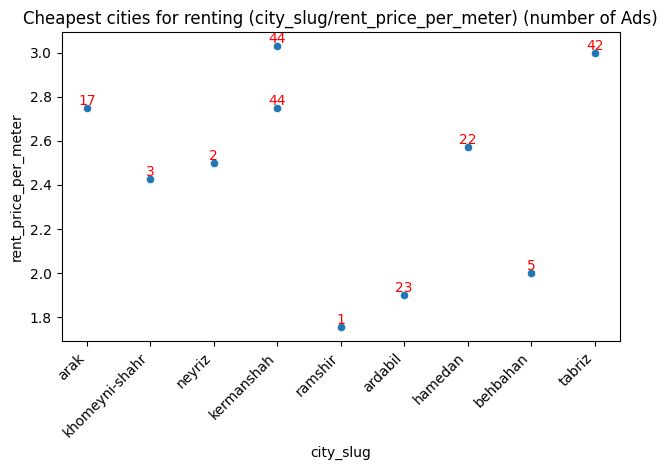

In [59]:
#cheap city for renting

Q1_r = data2['rent_price_per_meter'].quantile(0.25)
Q3_r = data2['rent_price_per_meter'].quantile(0.75)
IQR_r = Q3_r - Q1_r

# Define the lower and upper bounds for outliers
lower_bound_r = Q1_r - 1.5 * IQR_r
upper_bound_r = Q3_r + 1.5 * IQR_r

#consider non-outliers data
df_rent = data2[(data2['rent_price_per_meter'] >= lower_bound_r) & (data2['rent_price_per_meter'] <= upper_bound_r)]

df_rent = df_rent[data2['cat2_slug'].str.find('rent') != -1]

city_cheap_rent = df_rent[df_rent['rent_price_per_meter'] < Q1_r][['city_slug','rent_price_per_meter']]

city_cheap_rent.groupby('city_slug')['rent_price_per_meter'].mean().sort_values(ascending=False)

city_counts = city_cheap_rent['city_slug'].value_counts().reset_index(name='count')

city_cheap_rent = city_cheap_rent.merge(city_counts, on='city_slug')

#print(city_cheap_rent.head(10))
#plt.figure(figsize = (10, 5))

sns.scatterplot(x = 'city_slug', y = 'rent_price_per_meter', data = city_cheap_rent.head(10))
plt.title('Cheapest cities for renting (city_slug/rent_price_per_meter) (number of Ads)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
for i,row in city_cheap_rent.head(10).iterrows():
    plt.text(row['city_slug'], row['rent_price_per_meter'], str(row['count']), ha='center', va='bottom',color = 'red')

plt.show()